<style>
.nb-header {
    font-family: 'Inter', sans-serif;
}
</style>

<div style="
    padding: 40px;
    background-image: linear-gradient(rgba(0,0,0,0.6), rgba(0,0,0,0.6)),
                      url('https://agri-route.com/cdn/shop/articles/wepik-2022513-9459.jpg?v=1687588095&width=1100');
    background-size: cover;
    background-position: center;
    border-radius: 15px;
    color: white;
">
<p style="font-size:12px; letter-spacing:2px; color:#e2e8f0;">
📊 ML Project
</p>

<h1 style="margin:10px 0;">Exploratory Data Analysis</h1>

<p style="font-size:15px; color:#f1f5f9;">
Understanding data using visualization, patterns, and feature relationships.
</p>

</div>

**Contents**

1.  [Setup & Import](#1-setup--import)
2.  [Load Dataset](#2-datasetload)
3.  [Data quality & structure](#3-Data--quality--structure)
4.  [Targeting distribution](#4-Target--distribution)
5.  [Categorical feature analysis](#5-Categorical--feature--analysis)
6.  [Numrical feature analysis](#6-Categorical--feature--analysis)
7.  [Correlation betwwen feature](#7-Correlation)
8.  [Feature Engineering](#8-Feature--Engnerring)
9.  [EDA conclusions](#9-eda-conclusions)



<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">1</span>Setup &amp; imports
    </div>
</div>

In [1]:
# !pip install ipython

In [4]:
import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import HTML, display

PALETTE   = "YlGn"
ACCENT    = "#10b981"
DARK      = "#0f2d24"

sns.set_theme(style="whitegrid", palette="YlGn")
plt.rcParams.update({
    "figure.figsize":    (13, 5),
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   DARK,
    "axes.labelsize":    11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#fafafa",
    "grid.color":        "#e5e7eb",
})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">2</span>Load &amp; Data
    </div>
</div>

In [5]:
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
train_df=train_df.drop('id',axis=1)
print(f"Train:{train_df.shape[0]:,} rows ×{train_df.shape[1]} columns")
print(f"Test:{test_df.shape[0]:,} rows ×{test_df.shape[1]} columns")



Train:630,000 rows ×20 columns
Test:270,000 rows ×20 columns


In [6]:
def summrize_data(df:pd.DataFrame,label:str)->None:
    display(HTML(f"""
    <div style="border-left:5px solid #10b981; padding:10px 18px; background:#f0fdf4;
                border-radius:0 8px 8px 0; margin:12px 0; font-family:'Inter',sans-serif;">
        <b style="color:#065f46; font-size:15px;">{label}</b>
        <span style="margin-left:12px; color:#6b7280; font-size:13px;">
            {df.shape[0]:,} rows &times; {df.shape[1]} columns
        </span>
    </div>
    """))
    display(df.head())
    print()
    
summrize_data(train_df,"Training data")
summrize_data(test_df,  "Test data")



,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.9200,32.5800,1.0100,3.0500,15.0100,50.6100,725.9900,5.9000,16.7900,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.8200,No,112.1600,East,Low
1,Clay,7.0800,56.6100,0.4400,2.0000,22.9200,67.8600,985.6600,6.9800,3.3900,Wheat,Vegetative,Kharif,Rainfed,River,5.2700,Yes,47.1600,South,Low
2,Clay,5.6900,27.7100,0.8100,2.8300,26.9700,92.2200,"2,201.7000",6.0500,3.8500,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.2400,Yes,110.3800,North,Low
3,Sandy,5.6500,13.3200,1.3300,0.8700,13.3200,61.5700,"1,357.3300",9.1200,2.3100,Wheat,Flowering,Kharif,Canal,River,8.3200,Yes,53.8500,South,Medium
4,Clay,7.9600,59.1400,0.3800,0.9600,20.2200,91.1100,"1,538.2000",6.9500,13.9400,Wheat,Sowing,Rabi,Canal,River,7.3700,No,93.1900,South,Low


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.3600,26.1900,0.5900,2.8100,17.8300,30.2400,"1,533.3800",5.4000,3.0000,Maize,Sowing,Rabi,Canal,River,13.5900,Yes,47.4800,West
1,630001,Clay,5.8700,9.8800,1.1800,3.2600,21.1800,78.0700,576.0500,7.2200,15.8800,Cotton,Sowing,Rabi,Drip,Reservoir,6.1200,Yes,56.4300,South
2,630002,Sandy,6.2200,26.5500,0.9600,0.8500,26.8700,60.3500,545.3000,9.4300,2.6300,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.1100,Yes,20.0000,East
3,630003,Clay,7.6800,53.5800,0.8300,0.5500,41.7400,36.0500,"1,211.0300",6.6900,1.8600,Maize,Harvest,Rabi,Canal,Groundwater,2.2700,No,102.9900,North
4,630004,Loamy,5.2300,59.0200,0.5400,2.1100,41.0800,52.4700,"1,321.9100",4.1100,5.7100,Cotton,Sowing,Kharif,Canal,Groundwater,12.3900,Yes,13.3300,Central


<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">3</span>Data quality  &amp; Strucutre
    </div>
</div>

In [7]:
print(f"----------Training Data-----------")
print(f"Missing values is : {train_df.isnull().sum().sum()}")
print(f"----------Test Data----------")
print(f"Missing values is : {test_df.isnull().sum().sum()}")

----------Training Data-----------
Missing values is : 0
----------Test Data----------
Missing values is : 0


In [8]:
quality_report = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "training_missing": train_df.isna().sum(),
    "test_missing": test_df.isna().sum(),
    "train_nunique": train_df.nunique(),
    "test_nunique": test_df.nunique()
}).sort_values(['training_missing', 'train_nunique'], ascending=[False, True])

num_cols = quality_report.select_dtypes(include='number').columns

display(
    quality_report.style
    .background_gradient(subset=["training_missing", "test_missing"], cmap="Reds")
    .highlight_max(subset=num_cols, color='green')
    .highlight_min(subset=num_cols, color='lightblue')
)

print(f"\nDuplicate rows — train: {train_df.duplicated().sum():,}  |  test: {test_df.duplicated().sum():,}")
print(f"Missing values  — train: {train_df.isna().any().any()}  |  test: {test_df.isna().any().any()}")


,dtype,training_missing,test_missing,train_nunique,test_nunique
Mulching_Used,object,0.000000,0.000000,2.000000,2.000000
Irrigation_Need,object,0.000000,nan,3.000000,nan
Season,object,0.000000,0.000000,3.000000,3.000000
Crop_Growth_Stage,object,0.000000,0.000000,4.000000,4.000000
Irrigation_Type,object,0.000000,0.000000,4.000000,4.000000
Soil_Type,object,0.000000,0.000000,4.000000,4.000000
Water_Source,object,0.000000,0.000000,4.000000,4.000000
Region,object,0.000000,0.000000,5.000000,5.000000
Crop_Type,object,0.000000,0.000000,6.000000,6.000000
Organic_Carbon,float64,0.000000,0.000000,131.000000,131.000000



Duplicate rows — train: 0  |  test: 0
Missing values  — train: False  |  test: False


In [9]:
num_features=train_df.select_dtypes(include=np.number).columns.tolist()
cat_features=train_df.select_dtypes(exclude=np.number).columns.tolist()

num_col=[c for c in num_features if c !='id']
cat_col=[c for c in cat_features if c !='Irrigation_Need']

Feature_report=pd.DataFrame({
    "Feature":['Numeric features','Categorical features','Target'],
    "Count":[len(num_col),len(cat_col),1],
    "Names":[num_col[:5],cat_col[:5],['Irrigation_Need']]
})
display(
    Feature_report.style.format({
        "Names": lambda x: "<br>".join(x)
    }).set_properties(**{"white-space": "pre-wrap"})
)


,Feature,Count,Names
0,Numeric features,11,Soil_pHSoil_MoistureOrganic_CarbonElectrical_ConductivityTemperature_C
1,Categorical features,8,Soil_TypeCrop_TypeCrop_Growth_StageSeasonIrrigation_Type
2,Target,1,Irrigation_Need



<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key findings
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
    <li>There are <b> no duplicate rows</b> in either the training or test dataset.</li>
    <li>Both datasets contain <b>no missing values</b>.</li>
    <li>The dataset consists of <b>11</b> numerical features and <b>8</b> categorical features.</li>
    <li>Categorical features have between <b>2</b> and <b>6</b> unique categories.</li>
</ul>

</div>

In [10]:
train_df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">4</span>Target  &amp; distribuation
    </div>
</div>

In [8]:
target_order=['Low','Medium','High']

target_dst=(
    train_df['Irrigation_Need']
    .value_counts()
    .reindex(target_order)
    .rename_axis('Class')
    .reset_index(name='Count')
)
target_dst['share']=target_dst['Count']/target_dst['Count'].sum()
display(
    target_dst.style
    .background_gradient(subset=["Count"], cmap="Blues")
    .background_gradient(subset=["share"], cmap="Greens")
    .format({"Count": "{:,}", "share": "{:.1%}"})
)


,Class,Count,share
0,Low,"369,917",58.7%
1,Medium,"239,074",37.9%
2,High,"21,009",3.3%


In [9]:
imbalanced_ratio=target_dst['Count'].max()/target_dst['Count'].min()
print(f"Imbalanced Ratio:{imbalanced_ratio:.2f}")

Imbalanced Ratio:17.61


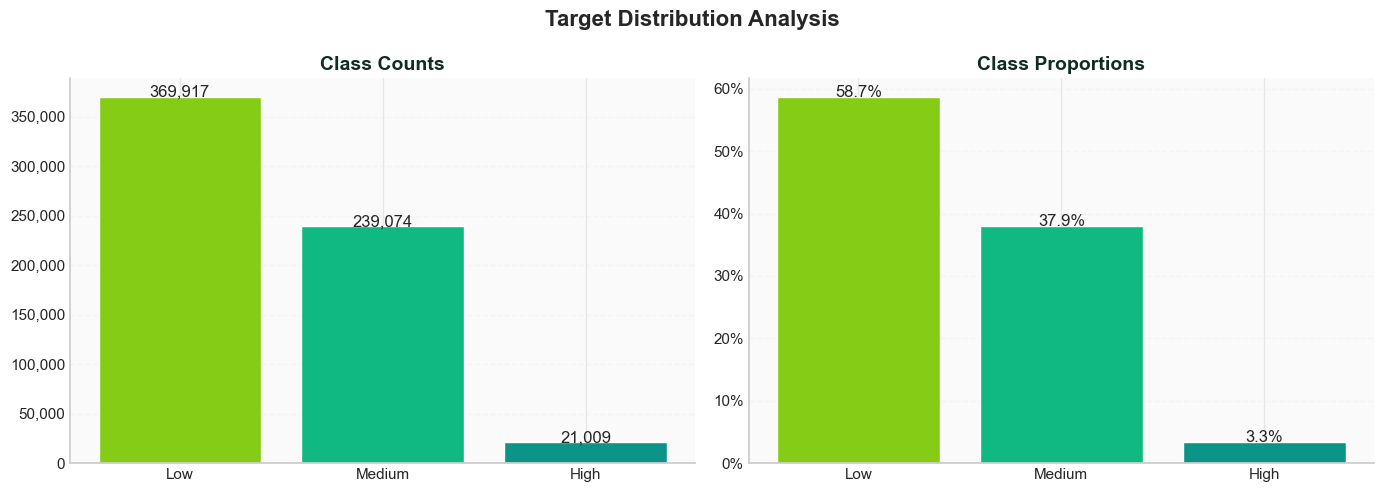

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#84cc16", "#10b981", "#0d9488"]
# Counts
axes[0].bar(target_dst["Class"], target_dst["Count"], color=colors)
axes[0].set_title("Class Counts")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, v in enumerate(target_dst["Count"]):
    axes[0].text(i, v, f"{v:,}", ha='center')
# Proportions
axes[1].bar(target_dst["Class"], target_dst["share"], color=colors)
axes[1].set_title("Class Proportions")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
for i, v in enumerate(target_dst["share"]):
    axes[1].text(i, v, f"{v:.1%}", ha='center')
for ax in axes:
    ax.tick_params(length=0)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
fig.suptitle("Target Distribution Analysis", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key findings
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
    <li>There are medium has <b>58.7</b> share and Low has a  <b>37.9</b> share.High has very low share <b>3.3</b></li>
    <li>Class imbalance ,should be consider when model selection and evalution.</li>
    
</ul>

</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">5</span>Categorical features  &amp; distribuation
    </div>
</div>

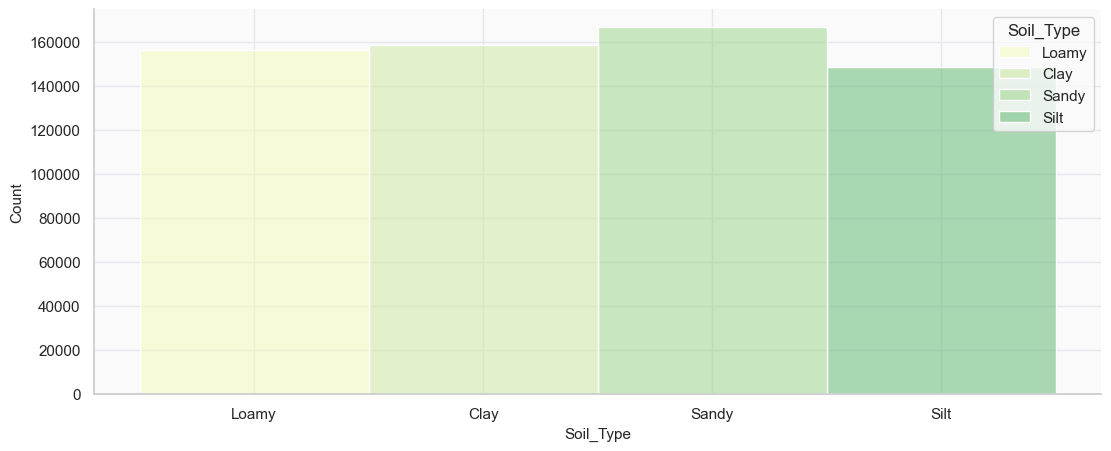

In [11]:

x=train_df['Soil_Type']
y=train_df['Irrigation_Need']
sns.histplot(data=train_df,x='Soil_Type',bins=30,kde='True',hue='Soil_Type')
plt.show()

In [12]:
cat_features

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region',
 'Irrigation_Need']

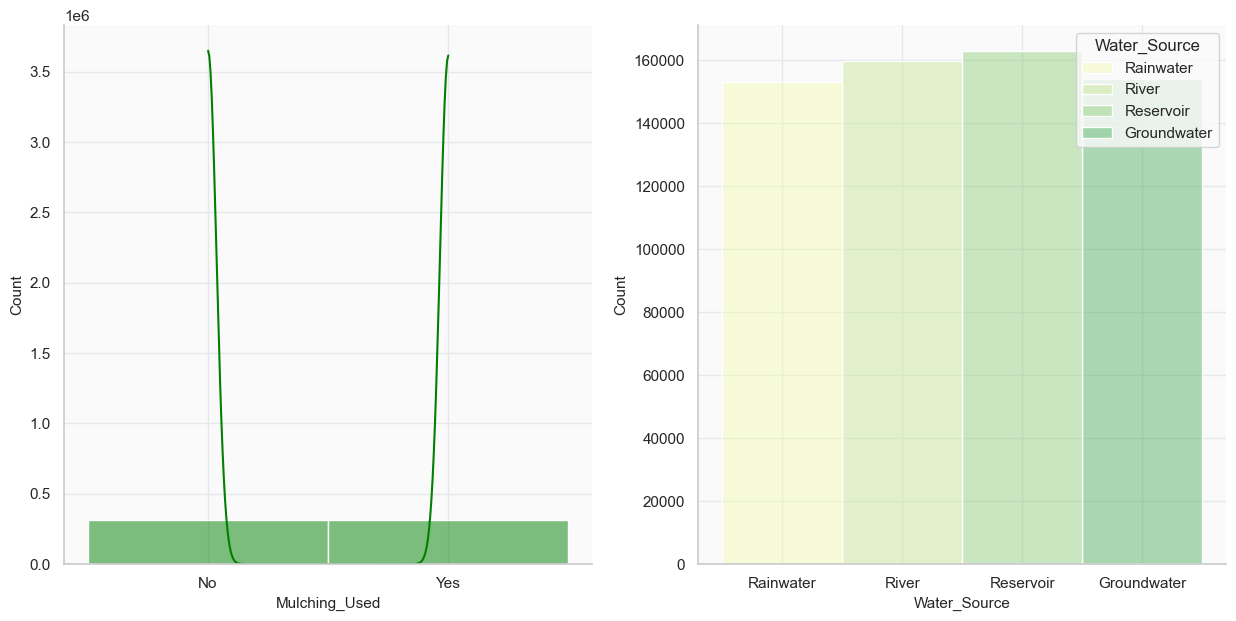

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=train_df,x='Mulching_Used',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=train_df,x='Water_Source',kde='True',hue='Water_Source')
plt.show()

In [14]:
water_percentage=['Rainwater', 'River', 'Reservoir', 'Groundwater']
target_dst=(
    train_df['Water_Source']
    .value_counts()
    .reindex(water_percentage)
    .rename_axis('Class')
    .reset_index(name='Count')
)
target_dst['share']=target_dst['Count']/target_dst['Count'].sum()
display(
    target_dst.style
    .background_gradient(subset=["Count"], cmap="Blues")
    .background_gradient(subset=["share"], cmap="Greens")
    .format({"Count": "{:,}", "share": "{:.1%}"})
)


,Class,Count,share
0,Rainwater,"153,032",24.3%
1,River,"159,819",25.4%
2,Reservoir,"162,994",25.9%
3,Groundwater,"154,155",24.5%


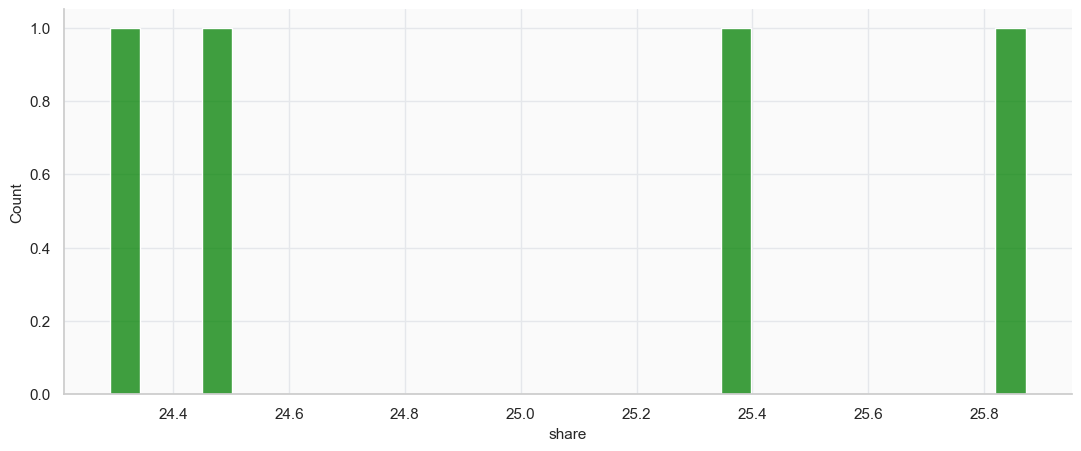

In [15]:
data=target_dst['share']*100

plt.Figure(figsize=(17,5))
sns.histplot(data=data,bins=30,color='g')
plt.show()

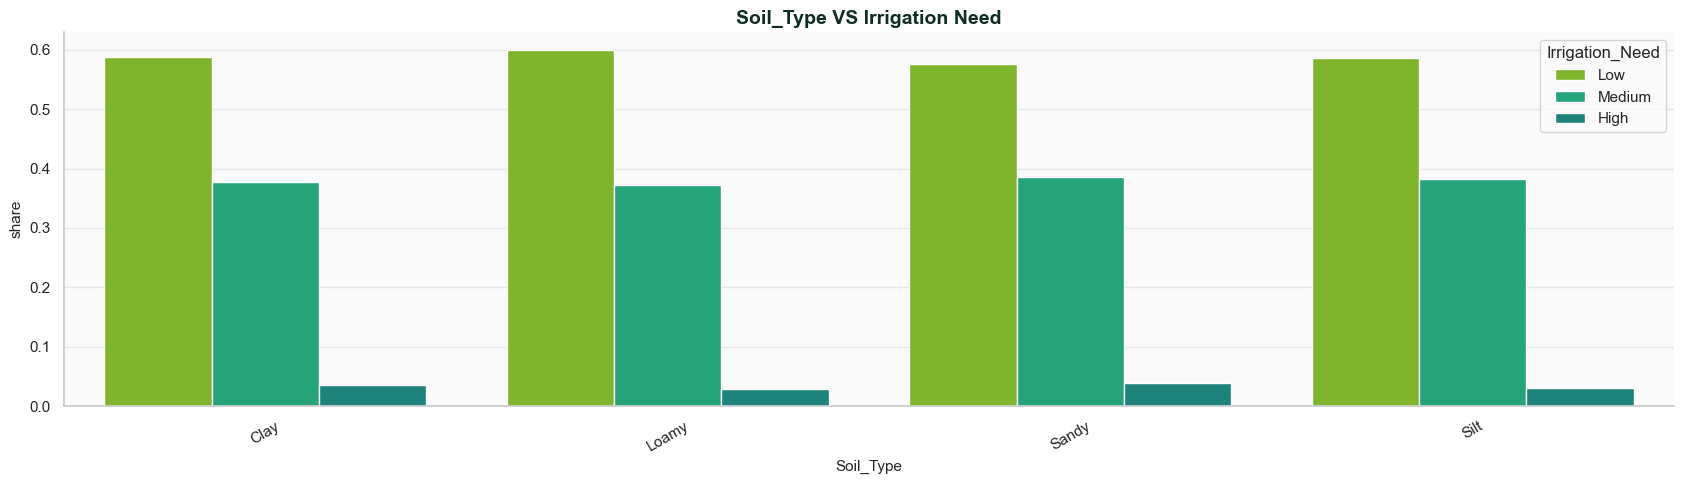

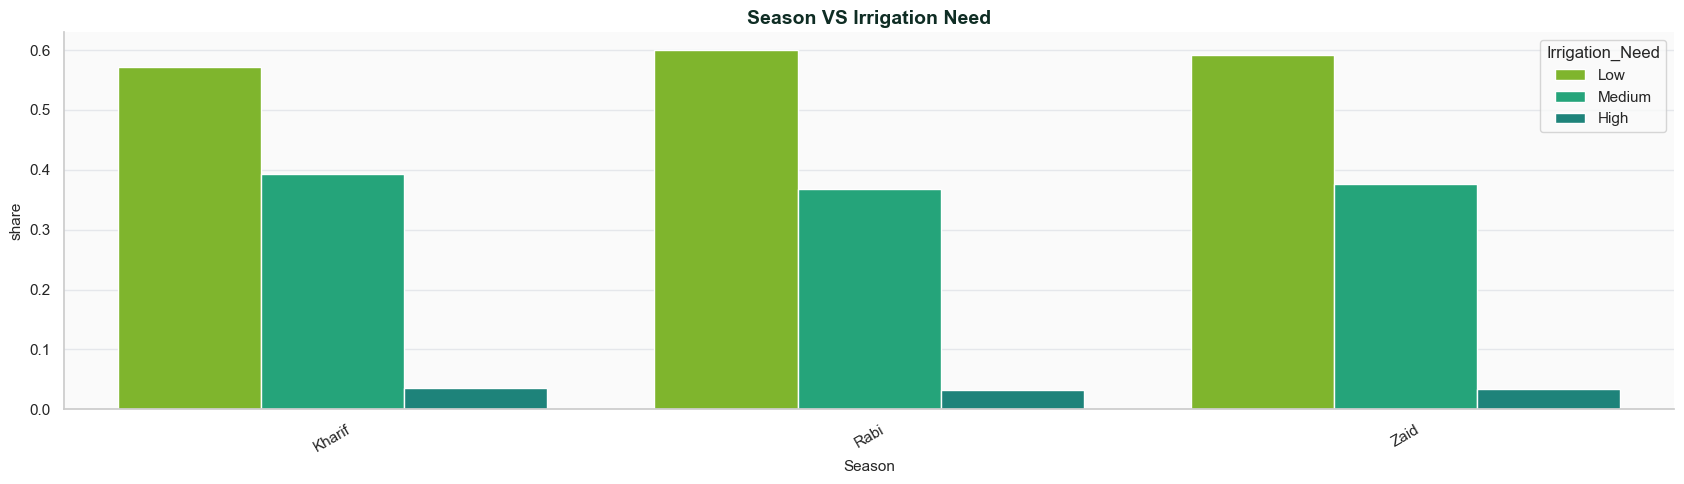

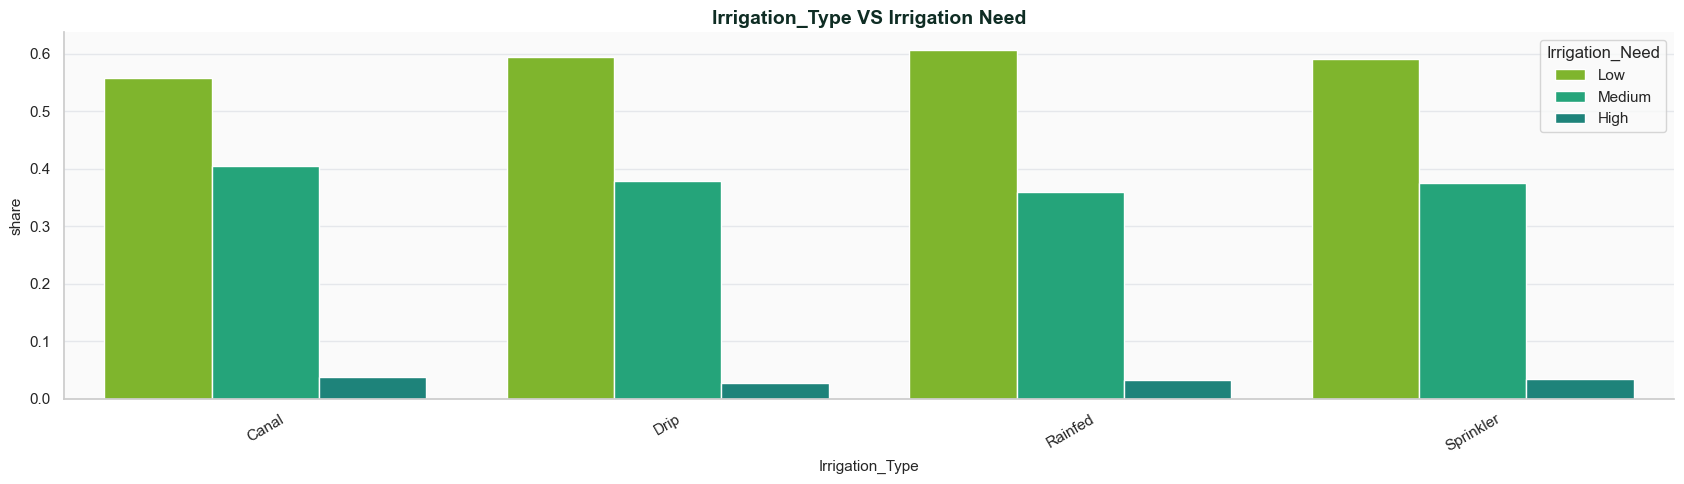

In [16]:
cat_focus = ["Soil_Type", "Season", "Irrigation_Type"]

for col in (cat_focus):
    prop = (
        train_df.groupby([col, "Irrigation_Need"]).size()
        .rename("count").reset_index()
    )
    total = prop.groupby(col)["count"].transform("sum")
    prop["share"] = prop["count"] / total
    
    plt.subplots(1,1,figsize=(17, 5))
    
    sns.barplot(data=prop,x=col,y='share',
                 hue_order=["Low", "Medium", "High"],hue='Irrigation_Need',
        palette=["#84cc16", "#10b981", "#0d9488"])
    
    plt.title(f"{col} VS Irrigation Need")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    

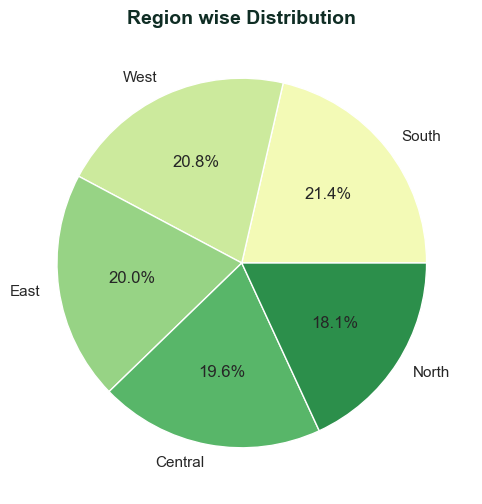

In [17]:
train_df['Region'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.ylabel("") 
plt.title("Region wise Distribution")
plt.show()

<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key findings
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
    <li>It is difficult to identify which categorical feature shows the strongest association with <b>'high'</b> irrigation need due to the strong class imbalance, which is evident across all categorical splits.</li>
    <li>All categorical features exhibit similar class distributions, with no clear differentiation between categories.</li>
    
</ul>

</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #2a2d0f 0%, #0d364a 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">6</span>Numrical features  &amp; distribuation
    </div>
</div>

In [18]:
num_features

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

<Axes: xlabel='Soil_pH', ylabel='Count'>

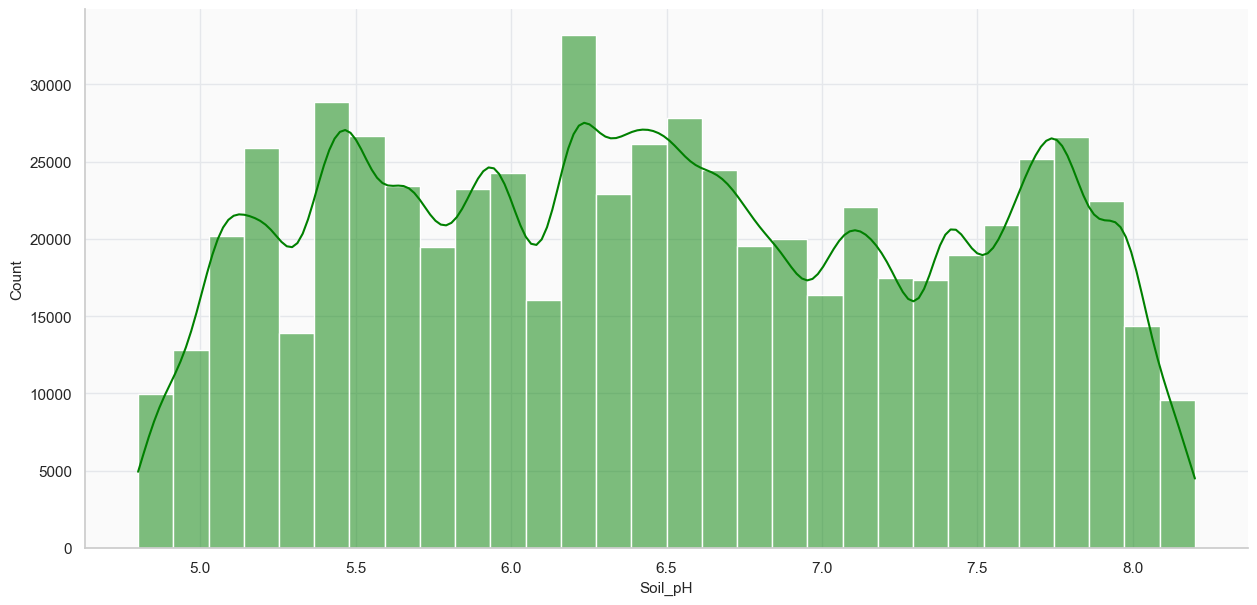

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(15, 7))
sns.histplot(data=train_df,x='Soil_pH',bins=30,kde=True,color='g')

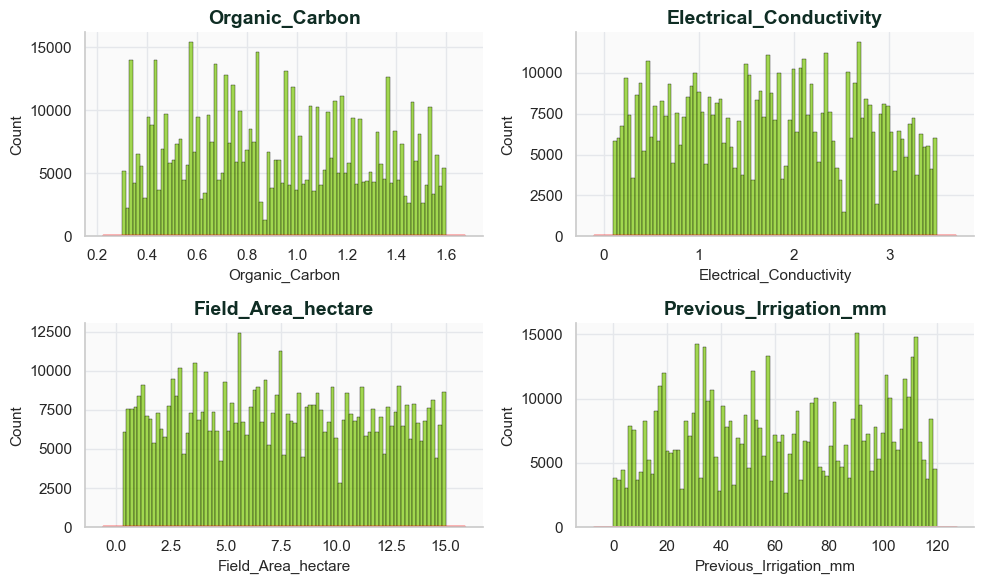

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

num_col = [
    'Organic_Carbon',
    'Electrical_Conductivity',
    'Field_Area_hectare',
    'Previous_Irrigation_mm'
]

for ax, col in zip(axes.ravel(), num_col):
    sns.histplot(train_df[col], ax=ax,color="#84cc16",edgecolor="black")
    
    sns.kdeplot(train_df[col], ax=ax, color="red", linewidth=2)
    ax.set_title(col)

plt.tight_layout()
plt.show()

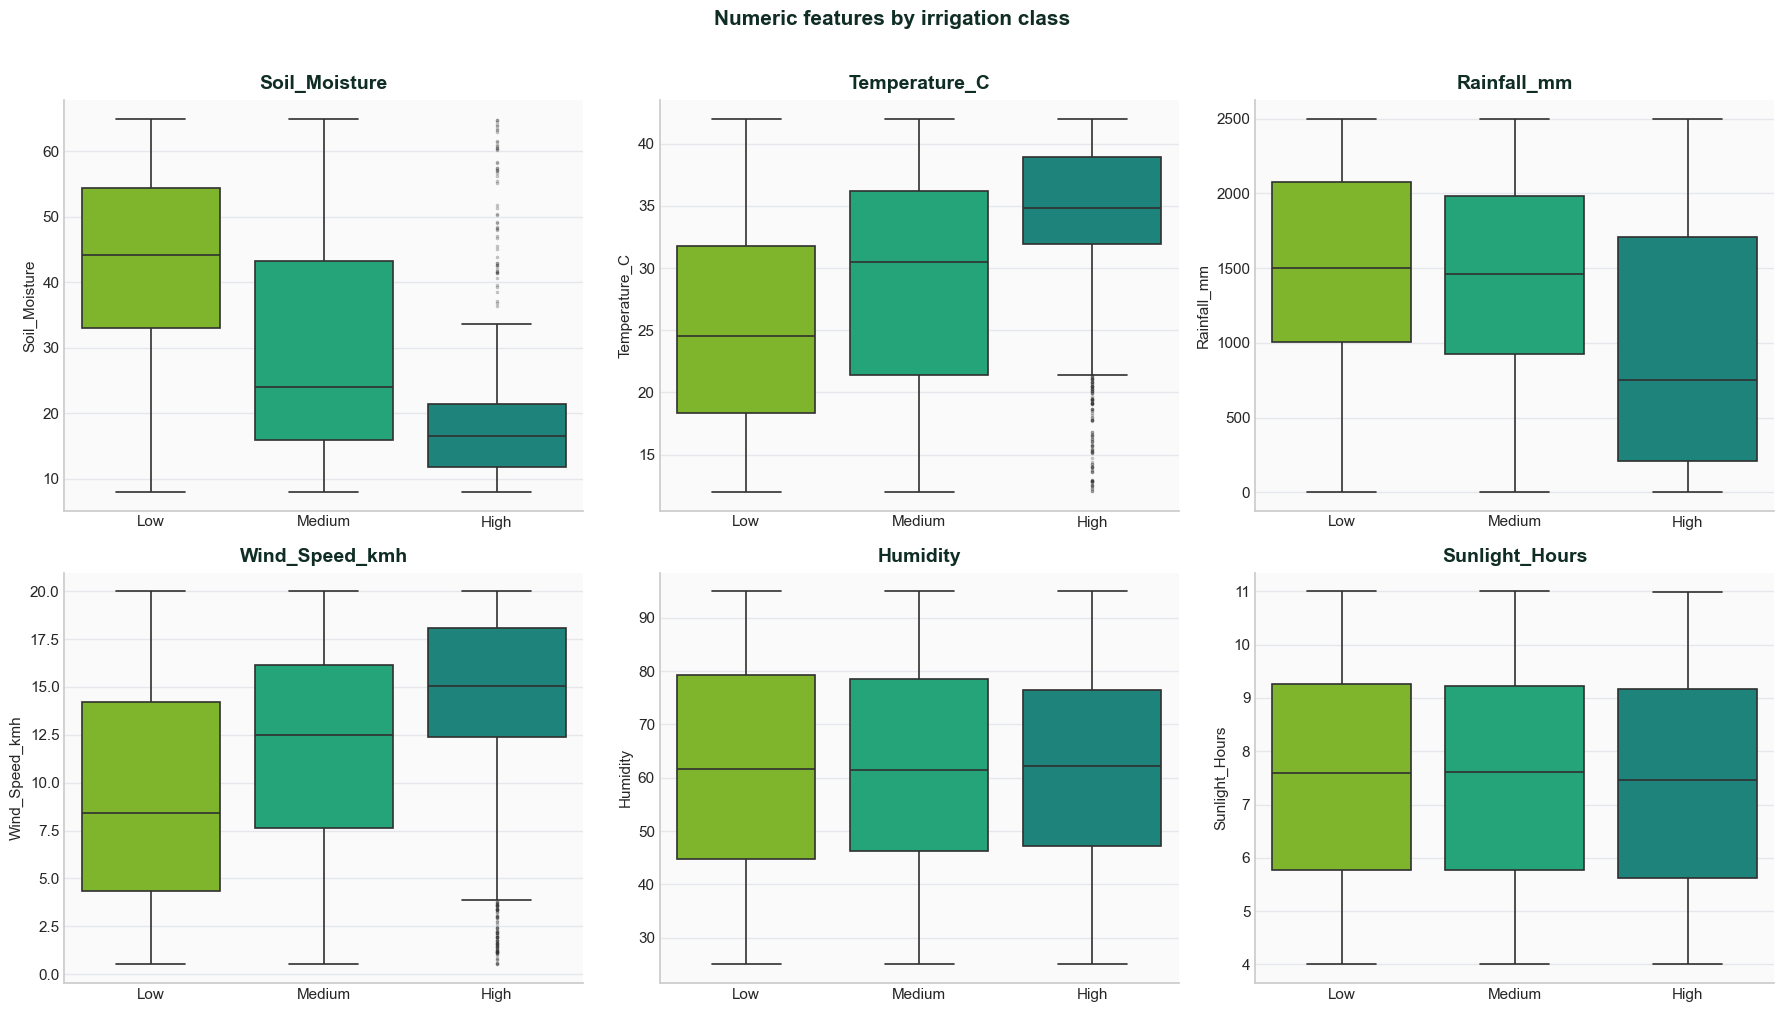

In [21]:
eda_sample = train_df.sample(80_000, random_state=42)

key_numeric = ["Soil_Moisture", "Temperature_C", "Rainfall_mm", "Wind_Speed_kmh",
               "Humidity", "Sunlight_Hours"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, col in zip(axes, key_numeric):
    sns.boxplot(
        data=eda_sample, x="Irrigation_Need", y=col,
        order=["Low", "Medium", "High"],
        palette=["#84cc16", "#10b981", "#0d9488"], ax=ax,
        linewidth=1.2, flierprops=dict(marker=".", alpha=0.3, markersize=3)
    )
    ax.set_title(f"{col}", pad=8)
    ax.set_xlabel("")
    ax.tick_params(length=0)

plt.suptitle("Numeric features by irrigation class", y=1.01, fontsize=15, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key findings
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
    <li>Soil Moisture <b>↓</b> → Irrigation <b>↑</b> (strongest signal)</li>
    <li>Rainfall <b>↓</b> → Irrigation <b>↑</b> (very strong)</li>
    <li>Temperature <b>↑</b> → Irrigation <b>↑</b></li>
    <li>Wind Speed <b>↑</b> → Irrigation <b>↑</b></li>
    <li>Organic Carbon → fairly uniform distribution, no strong skew</li>
    <li>Electrical Conductivity → spread out, no clear dominant range</li>
    <li>Field Area → evenly distributed, wide variation</li>
    <li>Previous Irrigation → broad range, no strong pattern</li>
    <li>Soil pH → centered around 6–7 (slightly acidic to neutral) → ideal for crops</li>
    
</ul>

</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #0f2d24 0%, #0d4a3e 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">7</span>Correlation structure
    </div>
</div>

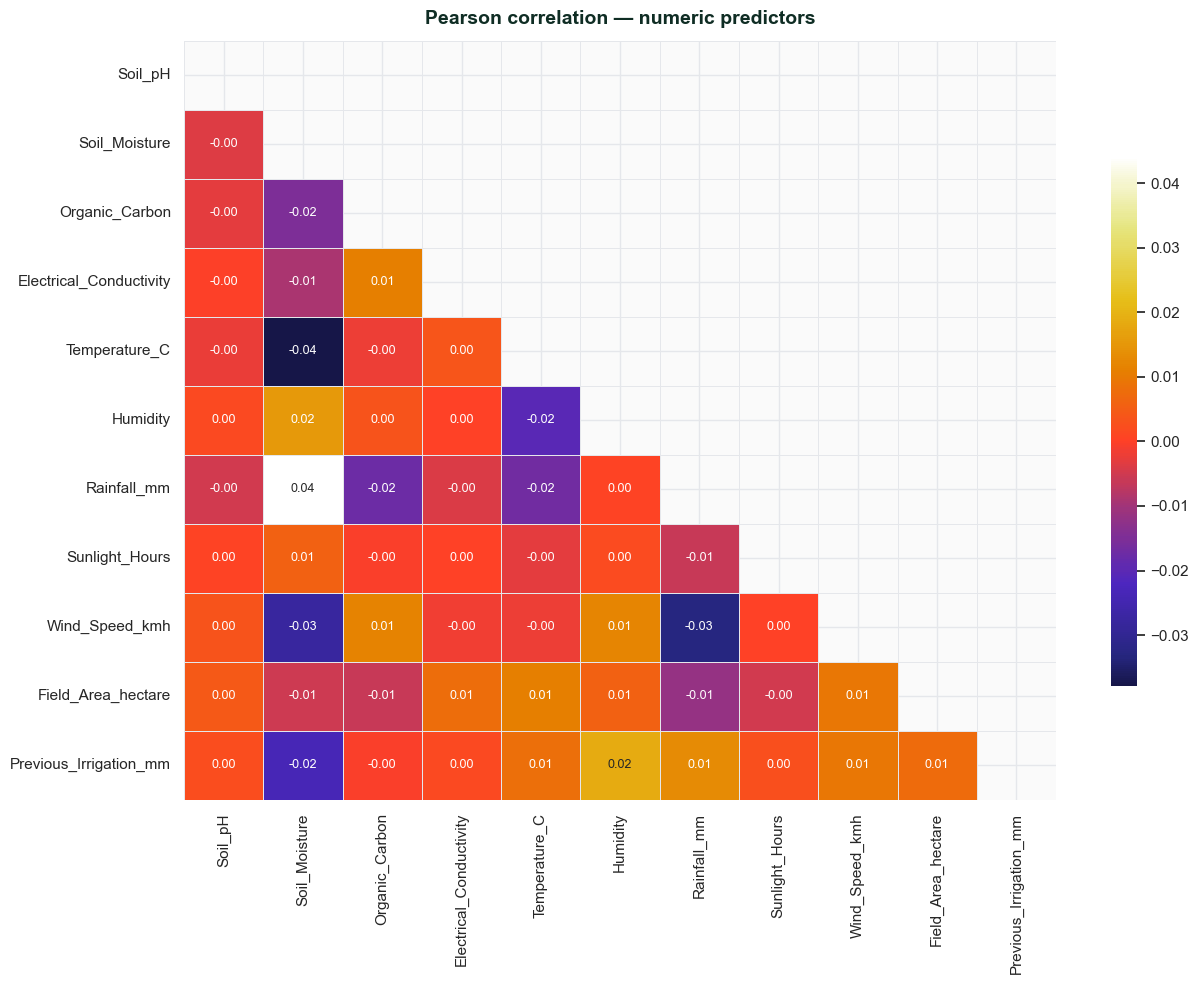

In [22]:
corr = train_df[num_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap="CMRmap", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.5, linecolor="#e5e7eb",
    cbar_kws={"shrink": 0.7}, ax=ax
)
ax.set_title("Pearson correlation — numeric predictors", pad=12)
plt.tight_layout()
plt.show()


<table border="1" cellpadding="8" cellspacing="0">
    <tr>
        <th>Coefficient Value</th>
        <th>Strength of Relationship</th>
    </tr>
    <tr>
        <td>+1.0</td>
        <td>Perfect positive linear relationship</td>
    </tr>
    <tr>
        <td>0.7 to 0.9</td>
        <td>High / Strong positive correlation</td>
    </tr>
    <tr>
        <td>0.5 to 0.7</td>
        <td>Moderate positive correlation</td>
    </tr>
    <tr>
        <td>0.0</td>
        <td>No linear relationship</td>
    </tr>
    <tr>
        <td>-1.0</td>
        <td>Perfect negative linear relationship</td>
    </tr>
</table>

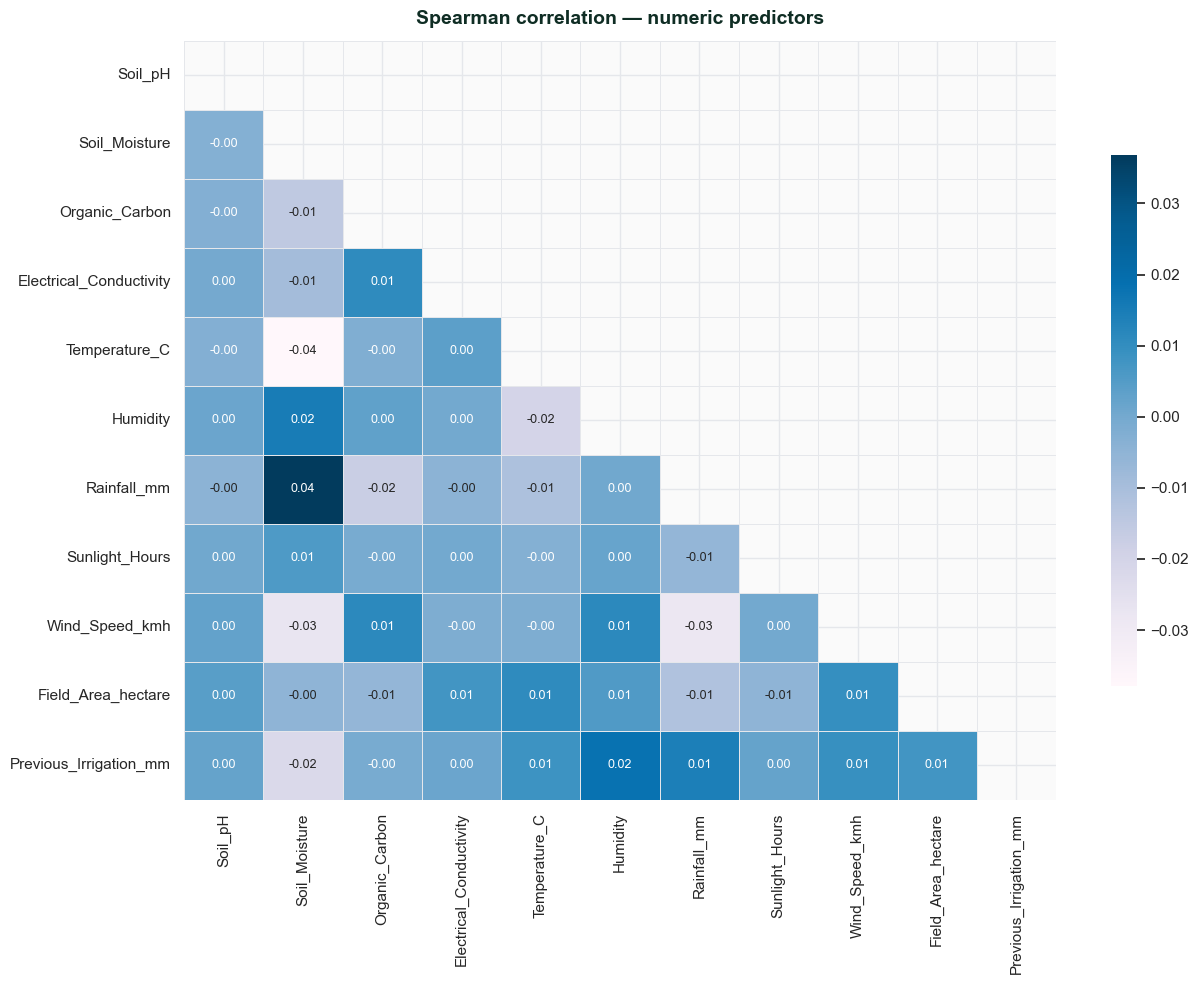

In [23]:
corr=train_df[num_features].corr(method='spearman')
fig,ax=plt.subplots(figsize=(13,10))
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(
    corr,mask=mask,cmap='PuBu',center=0,annot=True,
    fmt=".2f",annot_kws={"size":9},
    linewidths=0.5,linecolor="#e5e7eb",
    cbar_kws={"shrink":0.7},ax=ax
)
ax.set_title("Spearman correlation — numeric predictors",pad=12)
plt.tight_layout()
plt.show()

<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key findings
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
    <li>All numerical features show <b>very weak correlations</b>, with coefficients close to zero.</li>
        <li>This indicates <b>minimal linear dependence</b> and a low risk of multicollinearity among predictors.</li>
        <li><b>Pearson and Spearman correlations are highly consistent</b>, suggesting no significant non-linear monotonic relationships.</li>
        <li>No feature pairs demonstrate strong positive or negative correlation, so <b>feature removal due to redundancy is not necessary</b>.</li>
    
</ul>

</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #0f2d24 0%, #0d4a3e 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">8</span>Feature Engineering
    </div>
</div>

In [24]:
def add_features(df:pd.DataFrame)->pd.DataFrame:
    out=df.copy()
    # temp*sunlight/humidity
    out['Stress_Index']=(
        (out['Temperature_C'] *out['Sunlight_Hours']) /(out['Humidity']+1)
    )
    out['temp_humidity']=out['Temperature_C']/out['Humidity']
    
    out['Rainfall_Efficiency']=(out['Humidity']*out['Rainfall_mm'])/(out['Temperature_C']+1)
    return out
train_fe=add_features(train_df)
test_fe=add_features(test_df)
ENG_COLS=['Stress_Index','temp_humidity','Rainfall_Efficiency']
display(train_fe[ENG_COLS].describe().T.style.format("{:.3f}"))
display(test_fe[ENG_COLS].describe().T.style.format("{:.3f}"))



,count,mean,std,min,25%,50%,75%,max
Stress_Index,630000.000,3.661,2.174,0.510,2.101,3.131,4.624,17.367
temp_humidity,630000.000,0.498,0.260,0.127,0.309,0.438,0.618,1.668
Rainfall_Efficiency,630000.000,3601.681,2435.163,0.521,1840.060,3035.370,4765.006,17925.868


,count,mean,std,min,25%,50%,75%,max
Stress_Index,270000.000,3.665,2.175,0.509,2.102,3.138,4.631,16.981
temp_humidity,270000.000,0.498,0.260,0.126,0.310,0.439,0.619,1.676
Rainfall_Efficiency,270000.000,3608.593,2448.373,1.361,1840.506,3040.507,4761.738,17724.135


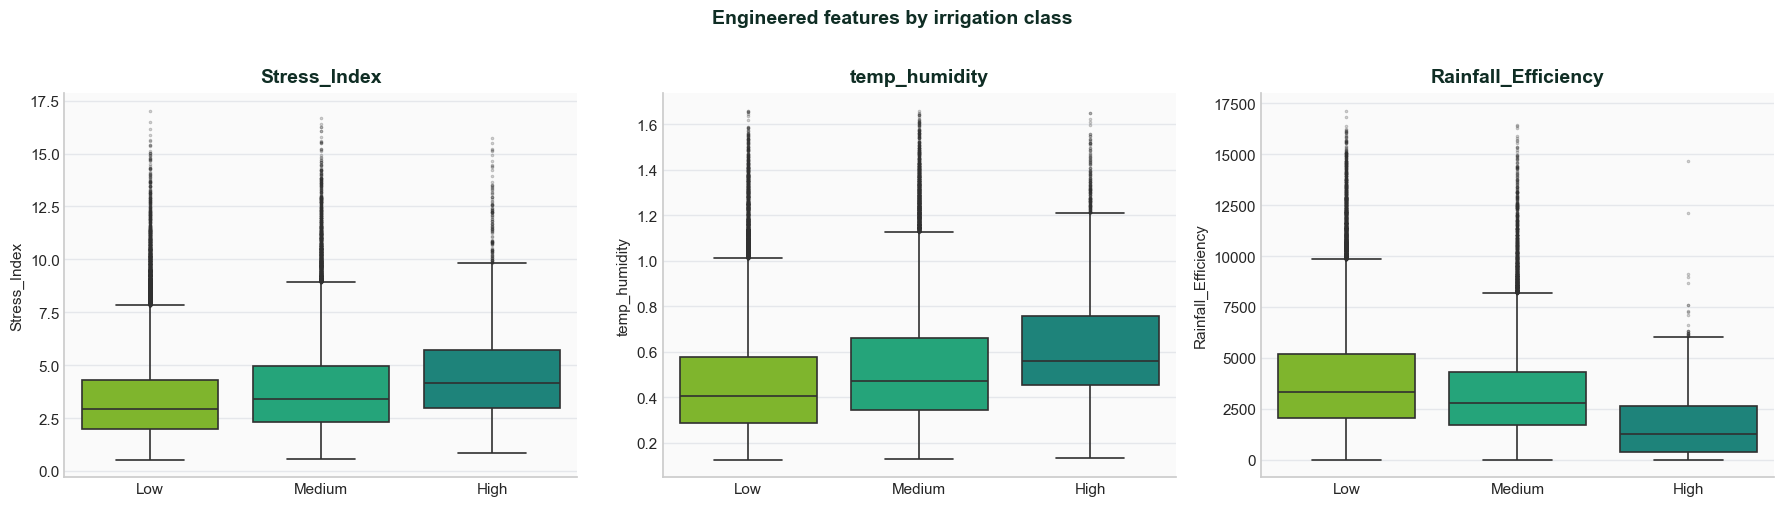

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_fe = train_fe.sample(80_000, random_state=42)

for ax, col in zip(axes, ENG_COLS):
    sns.boxplot(
        data=sample_fe, x="Irrigation_Need", y=col,
        order=["Low", "Medium", "High"],
        palette=["#84cc16", "#10b981", "#0d9488"], ax=ax,
        linewidth=1.2, flierprops=dict(marker=".", alpha=0.3, markersize=3)
    )
    ax.set_title(col, pad=8)
    ax.set_xlabel("")
    ax.tick_params(length=0)

plt.suptitle("Engineered features by irrigation class", y=1.01, fontsize=14, fontweight="bold", color=DARK)
plt.tight_layout()
plt.show()


<div class="nb-note-box" style="
    padding: 18px 24px;
    background: #f9fafa;
    border: 1.5px dashed #a3a3a3;
    border-radius: 10px;
    margin: 14px 0;
">
<span style="font-weight:600; color:#111;">
✏ Key Feature Engineering Insights
</span>

<ul style="margin:0; padding-left:18px; font-size:14px; color:#525252; line-height:1.6;">
   <li><b>Climate Stress Index:</b> Shows a clear increasing trend from <b>Low → Medium → High irrigation</b>, indicating that higher irrigation demand is driven by greater climate stress.</li>
   
   <li><b>Temp–Humidity Feature:</b> Gradually increases across irrigation levels, suggesting that combined temperature and humidity conditions contribute to higher irrigation needs.</li>
   
   <li><b>Rainfall Efficiency:</b> Decreases with increasing irrigation class, implying that high irrigation regions depend less on natural rainfall and more on artificial irrigation.</li>
</ul>

</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #0f2d24 0%, #0d4a3e 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
        <span style="opacity:0.55; font-weight:500; margin-right:10px;">9</span>EDA Conclusion
    </div>
</div>

<div style="
    padding: 22px 28px;
    background: linear-gradient(135deg, #f0fdf4 0%, #ecfdf5 100%);
    border-radius: 12px;
    border: 1.5px solid #6ee7b7;
    margin: 20px 0;
    font-family: 'Inter', sans-serif;
">
<h3 style="margin:0 0 14px 0; color:#064e3b; font-size:17px; font-weight:700;">
    📋 Feature Engineering Conclusions
</h3>
<ul style="margin:0; padding-left:20px; color:#065f46; font-size:14px;">
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Data quality:</b> Dataset is clean with <b>no missing values</b> and <b>no duplicate rows</b>, requiring minimal preprocessing.
  </li>
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Class imbalance:</b> The <code>High</code> irrigation class is underrepresented compared to <code>Low</code> and <code>Medium</code>.
  </li>
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Weak original relationships:</b> Most individual numerical and categorical features show <b>weak correlation</b> with the target variable.
  </li>
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Categorical features:</b> No strong patterns or class separation observed across categories.
  </li>
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Engineered features impact:</b> Newly created features like <b>Climate Stress Index</b>, <b>Temp–Humidity</b>, and <b>Rainfall Efficiency</b> reveal <b>clear trends across irrigation levels</b>.
  </li>
  
  <li style='margin-bottom:8px; line-height:1.6;'>
  <b>Key insight:</b> <b>Feature combinations outperform individual variables</b>, making engineered features crucial for improving model performance.
  </li>

</ul>
</div>

<div class="nb-section" style="
    padding: 12px 22px;
    background: linear-gradient(90deg, #0f2d24 0%, #0d4a3e 100%);
    border-radius: 10px;
    border-left: 5px solid #84cc16;
    color: #f9fafb;
    margin: 28px 0 14px 0;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
">
    <div style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.2px; line-height:1.3; text-shadow:none;">
    <center>🙌 Thank you for reading my EDA  file</center> 
    </div>
</div>